# Assignment 3 (24.04.2026)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 3.1: Bayesian Linear Regression (25 points)
Implement Bayesian linear regression using PyMC:

• Use a polynomial regression problem with noisy data (use synthetic data
or Advertising Dataset from Kaggle).

• Set appropriate priors for coefficients and noise.

• Sample from the posterior using MCMC.

• Visualize posterior distributions and credible intervals.

• Compare with standard maximum likelihood estimation.

### Quadratic Bayesian Regression

We model

$$
Y_i \sim \mathcal{N}(\mu_i,\sigma),\qquad
\mu_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2.
$$

Goals:
1. Generate synthetic data ($n=60$).
2. Specify priors for $\beta_0,\beta_1,\beta_2,\sigma$.
3. Perform prior predictive check.
4. Define expected value and likelihood.
5. Sample from posterior using multiple chains.
6. Plot posterior densities and traces.
7. Visualize 95% credible intervals for each parameter.
8. Plot posterior mean curve + 95% band and compare to true curve + MLE curve.
9. Compute 95% credible intervals for $Y_i$ and compare with observed data.

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


True params: beta0=1.0, beta1=-1.5, beta2=0.9, sigma=1.2
MLE params : beta0=1.316, beta1=-1.329, beta2=0.888, sigma=1.127


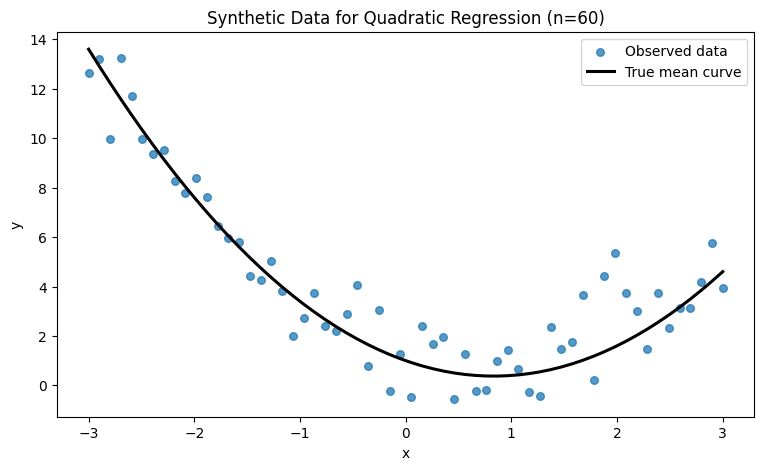

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm  # Bayesian modeling library
import arviz as az  # For summarizing and plotting Bayesian inference results

rng = np.random.default_rng(2026)

# True data-generating parameters
beta0_true = 1.0
beta1_true = -1.5
beta2_true = 0.9
sigma_true = 1.2
n = 60

x = np.linspace(-3, 3, n)
mu_true = beta0_true + beta1_true * x + beta2_true * x**2
y = rng.normal(mu_true, sigma_true)

# MLE under Gaussian homoskedastic noise (equivalent to OLS)
X = np.column_stack([np.ones_like(x), x, x**2])
beta_mle = np.linalg.lstsq(X, y, rcond=None)[0]
mu_mle = X @ beta_mle
sigma_mle = np.sqrt(np.mean((y - mu_mle) ** 2))

print(f'True params: beta0={beta0_true}, beta1={beta1_true}, beta2={beta2_true}, sigma={sigma_true}')
print(f'MLE params : beta0={beta_mle[0]:.3f}, beta1={beta_mle[1]:.3f}, beta2={beta_mle[2]:.3f}, sigma={sigma_mle:.3f}')

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=30, alpha=0.75, label='Observed data')
plt.plot(x, mu_true, color='black', linewidth=2.2, label='True mean curve')
plt.title('Synthetic Data for Quadratic Regression (n=60)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Sampling: [beta0, beta1, beta2, sigma, y_obs]


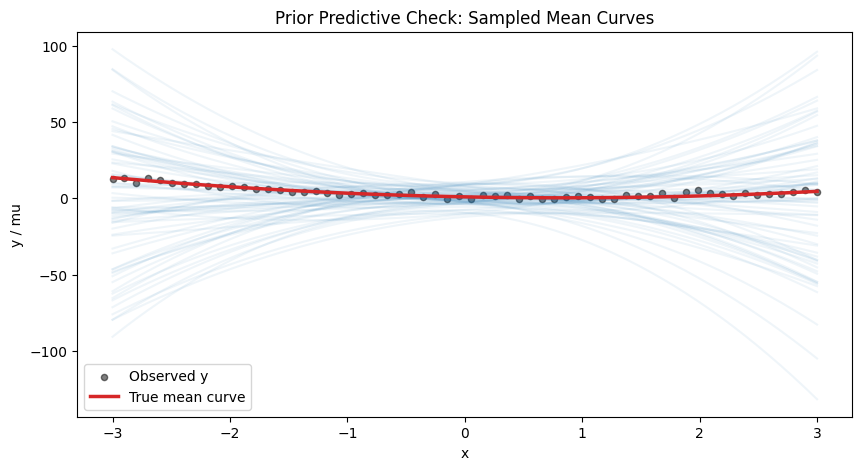

In [ ]:
with pm.Model() as quad_model:
    # Priors
    beta0 = pm.Normal('beta0', mu=0.0, sigma=5.0)
    beta1 = pm.Normal('beta1', mu=0.0, sigma=5.0)
    beta2 = pm.Normal('beta2', mu=0.0, sigma=5.0)
    sigma = pm.HalfNormal('sigma', sigma=3.0)  # HalfNormal prior for positive scale parameter

    # Expected value and likelihood
    mu = pm.Deterministic('mu', beta0 + beta1 * x + beta2 * x**2)  # Deterministic variable for the mean function
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)  # Likelihood of observed data

    # Prior predictive check
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=2026)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, s=20, alpha=0.5, color='black', label='Observed y')
for i in range(70):
    ax.plot(x, prior_pred.prior['mu'][0, i], color='tab:blue', alpha=0.07)
ax.plot(x, mu_true, color='tab:red', linewidth=2.5, label='True mean curve')
ax.set_title('Prior Predictive Check: Sampled Mean Curves')
ax.set_xlabel('x')
ax.set_ylabel('y / mu')
ax.legend()
plt.show()

In [ ]:
with quad_model:
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.9,  # Higher target_accept to reduce step size and improve convergence
        random_seed=2026,
        return_inferencedata=True
    )
    post_pred = pm.sample_posterior_predictive(idata, var_names=['y_obs', 'mu'], random_seed=2026)

# Combine posterior predictive into one object for convenient diagnostics
idata.extend(post_pred)

display(az.summary(idata, var_names=['beta0', 'beta1', 'beta2', 'sigma'], hdi_prob=0.95))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Sampling: [y_obs]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,1.311,0.229,0.854,1.748,0.003,0.002,5288.0,5133.0,1.0
beta1,-1.329,0.088,-1.508,-1.159,0.001,0.001,6528.0,4887.0,1.0
beta2,0.889,0.055,0.781,0.995,0.001,0.001,5399.0,5444.0,1.0
sigma,1.183,0.115,0.957,1.401,0.001,0.001,6430.0,5391.0,1.0


/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_96956/3688740624.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  mu_hdi = az.hdi(mu_post, hdi_prob=0.95)
/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_96956/3688740624.py:16: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_post, hdi_prob=0.95)


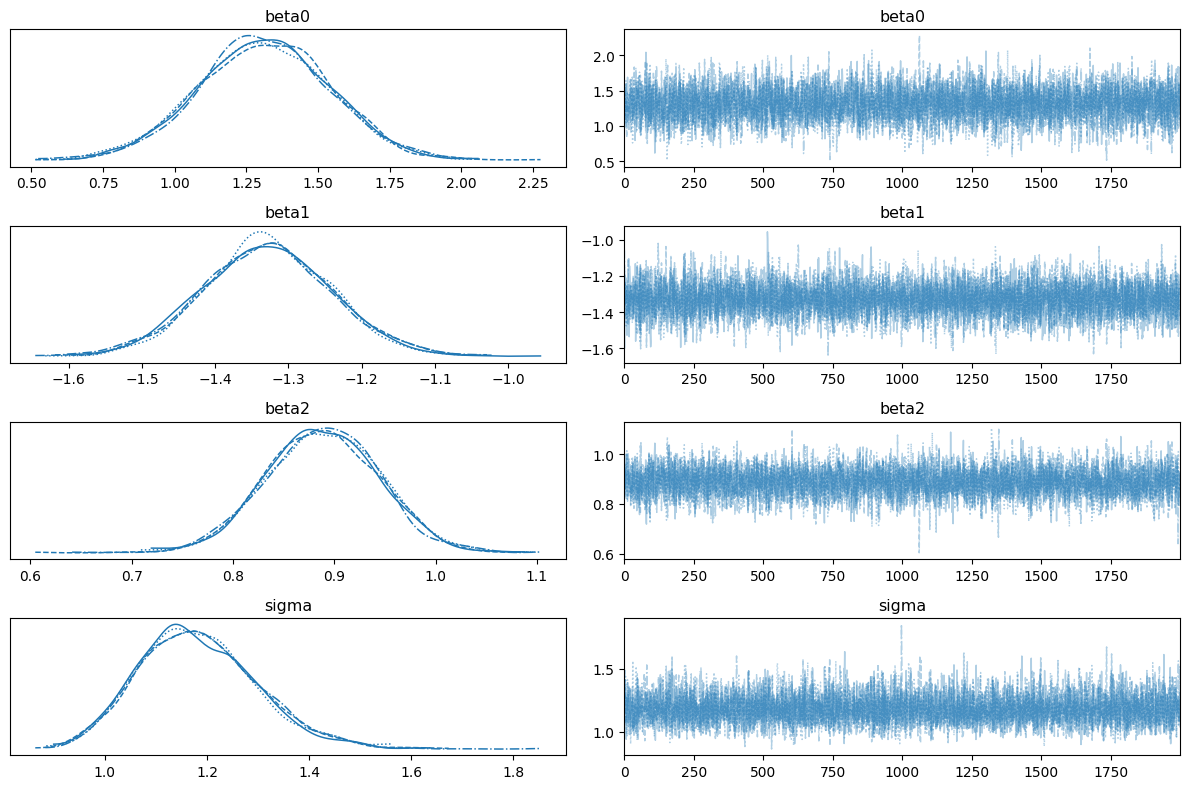

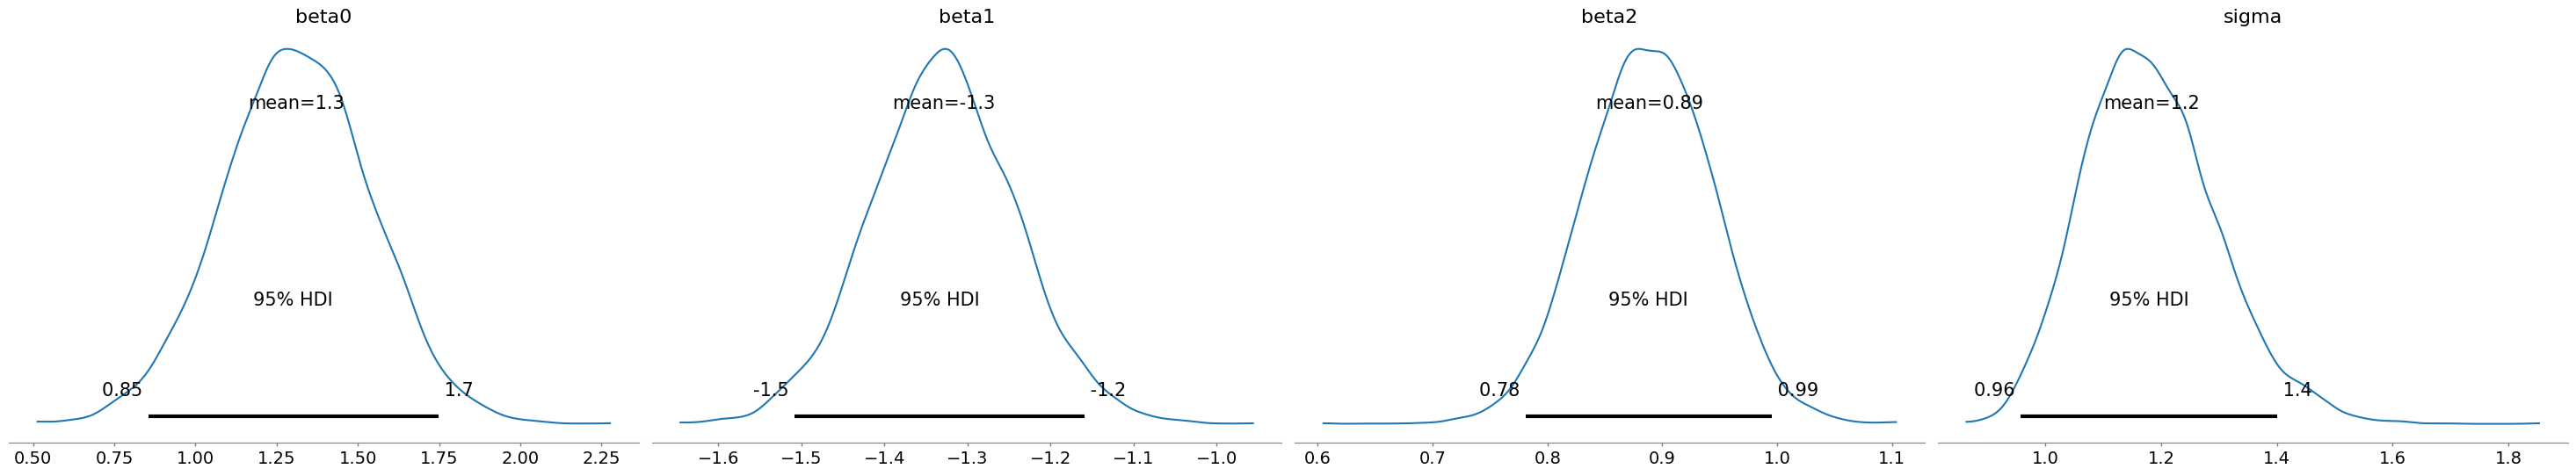

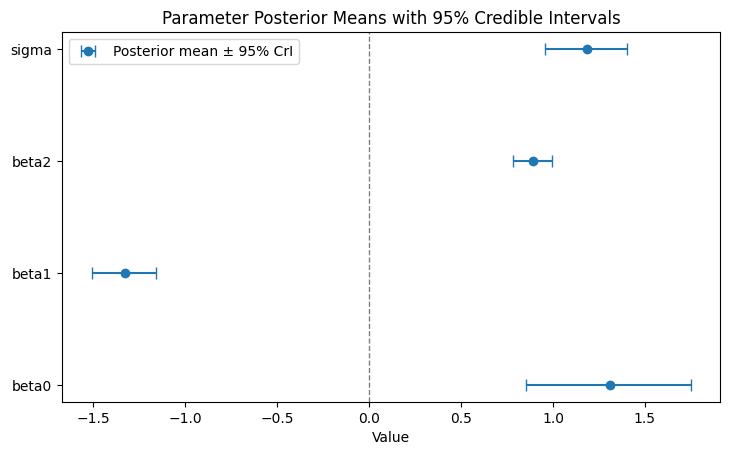

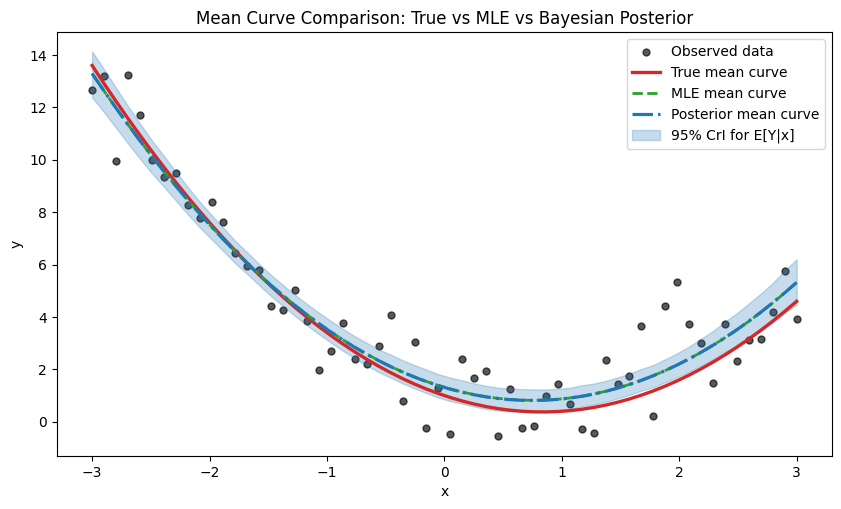

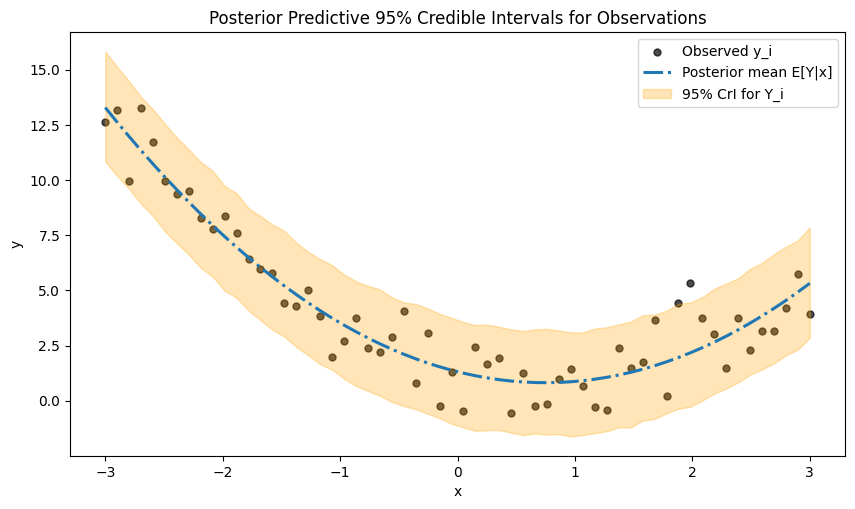

In [5]:
# Posterior samples (flatten chain, draw)
b0 = idata.posterior['beta0'].values.reshape(-1)
b1 = idata.posterior['beta1'].values.reshape(-1)
b2 = idata.posterior['beta2'].values.reshape(-1)
sig = idata.posterior['sigma'].values.reshape(-1)

mu_post = (
    b0[:, None]
    + b1[:, None] * x[None, :]
    + b2[:, None] * (x[None, :] ** 2)
)
y_post = rng.normal(mu_post, sig[:, None])

mu_mean = mu_post.mean(axis=0)
mu_hdi = az.hdi(mu_post, hdi_prob=0.95)
y_hdi = az.hdi(y_post, hdi_prob=0.95)

# 1) Posterior densities and traces
az.plot_trace(idata, var_names=['beta0', 'beta1', 'beta2', 'sigma'])
plt.tight_layout()
plt.show()

az.plot_posterior(idata, var_names=['beta0', 'beta1', 'beta2', 'sigma'], hdi_prob=0.95)
plt.tight_layout()
plt.show()

# 2) 95% credible intervals for each parameter
summary = az.summary(idata, var_names=['beta0', 'beta1', 'beta2', 'sigma'], hdi_prob=0.95)
param_names = ['beta0', 'beta1', 'beta2', 'sigma']
means = summary.loc[param_names, 'mean'].values
lower = summary.loc[param_names, 'hdi_2.5%'].values
upper = summary.loc[param_names, 'hdi_97.5%'].values

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ypos = np.arange(len(param_names))
ax.errorbar(
    means,
    ypos,
    xerr=[means - lower, upper - means],
    fmt='o',
    capsize=4,
    label='Posterior mean ± 95% CrI'
)
ax.set_yticks(ypos)
ax.set_yticklabels(param_names)
ax.axvline(0.0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Parameter Posterior Means with 95% Credible Intervals')
ax.set_xlabel('Value')
ax.legend()
plt.show()

# 3) Posterior mean curve + 95% credible band vs true and MLE curves
plt.figure(figsize=(10, 5.5))
plt.scatter(x, y, s=25, alpha=0.65, color='black', label='Observed data')
plt.plot(x, mu_true, color='tab:red', linewidth=2.4, label='True mean curve')
plt.plot(x, mu_mle, color='tab:green', linewidth=2.0, linestyle='--', label='MLE mean curve')
plt.plot(x, mu_mean, color='tab:blue', linewidth=2.3, linestyle='-.', label='Posterior mean curve')
plt.fill_between(x, mu_hdi[:, 0], mu_hdi[:, 1], color='tab:blue', alpha=0.25, label='95% CrI for E[Y|x]')
plt.title('Mean Curve Comparison: True vs MLE vs Bayesian Posterior')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 4) 95% credible intervals for Y_i and comparison with data
plt.figure(figsize=(10, 5.5))
plt.scatter(x, y, s=25, alpha=0.7, color='black', label='Observed y_i')
plt.plot(x, mu_mean, color='tab:blue', linewidth=2.2, linestyle='-.', label='Posterior mean E[Y|x]')
plt.fill_between(x, y_hdi[:, 0], y_hdi[:, 1], color='orange', alpha=0.28, label='95% CrI for Y_i')
plt.title('Posterior Predictive 95% Credible Intervals for Observations')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Predicted mean curve using MLE and Bayesian regression overlap. True mean curve lies within 95% credible interval. Posterior distributions for $\beta_0,\beta_1,\beta_2$ are centered around true values with reasonable spread. Trace plots show good mixing and convergence. 95% credible intervals for $Y_i$ capture most observed data points, with 2 outliers (95% interval captures 58/60 points).

## Problem 3.2: Gaussian Process Regression (25 points)
Apply Gaussian Processes to function approximation:

• Use GPyTorch or scikit-learn.

• Test on synthetic 1D and 2D functions.

• Use Mauna Loa CO2 dataset or temperature time series from your hometown

• Experiment with different kernels (RBF, Matern, Periodic).

• Visualize mean predictions and uncertainty bounds.

• Discuss computational complexity for large datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel, ExpSineSquared, RationalQuadratic, Matern, DotProduct


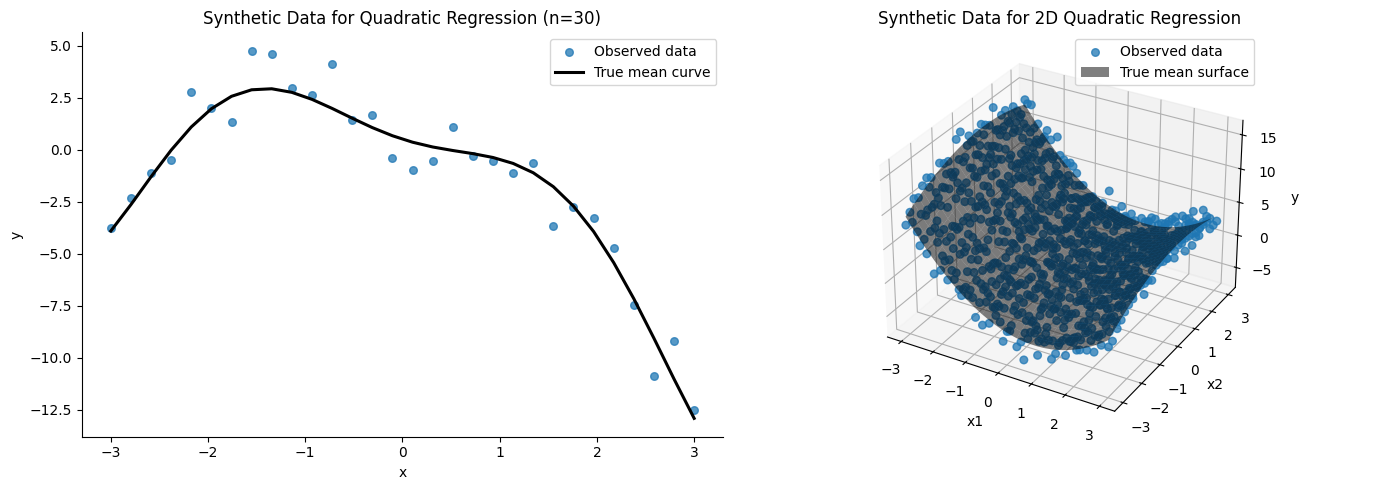

In [15]:
f = lambda x: x**2 * np.cos(x) - 1.5 * x + 0.5
x = np.linspace(-3, 3, 30)
y = f(x) + np.random.normal(0, 1.2, size=x.shape)

# 2d function
f_2d = lambda x1, x2: 1.0 - 1.5 * x1 + 0.9 * x1**2 + 0.5 * x2 - 0.3 * x2**2
x1 = np.linspace(-3, 3, 30)
x2 = np.linspace(-3, 3, 30)
X1, X2 = np.meshgrid(x1, x2)
y_2d = f_2d(X1, X2) + np.random.normal(0, 1.2, size=X1.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(x, y, s=30, alpha=0.75, label='Observed data')
ax[0].plot(x, f(x), color='black', linewidth=2.2, label='True mean curve')
ax[0].set_title('Synthetic Data for Quadratic Regression (n=30)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].legend()

for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_visible(False)
ax[0].spines['bottom'].set_visible(True)
ax[0].spines['left'].set_visible(True)
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[1] = fig.add_subplot(122, projection='3d')
ax[1].scatter(X1.flatten(), X2.flatten(), y_2d.flatten(), s=30, alpha=0.75, label='Observed data')
ax[1].plot_surface(X1, X2, f_2d(X1, X2), color='black', alpha=0.5, label='True mean surface')
ax[1].set_title('Synthetic Data for 2D Quadratic Regression')
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].set_zlabel('y')
ax[1].legend()

plt.tight_layout()
plt.show()

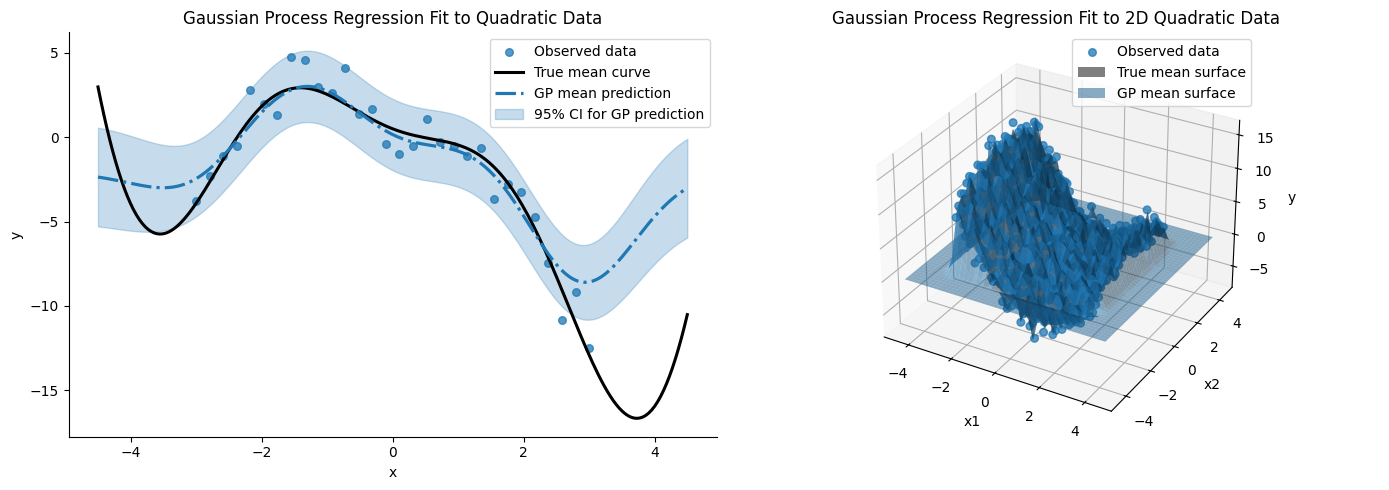

In [46]:
# 1d
kernel = (
    ExpSineSquared(length_scale=1.0, periodicity=3.0) 
    + RationalQuadratic(length_scale=1.0, alpha=1.0, length_scale_bounds=(1e-8, 1e5)) 
    + ConstantKernel(constant_value=2.0, constant_value_bounds=(1e-3, 1e4)) 
    )
# kernel = RationalQuadratic(length_scale=1.0, alpha=1.0, length_scale_bounds=(1e-8, 1e5))# + WhiteKernel(noise_level=1.2**2)
gp = GaussianProcessRegressor(kernel=kernel, random_state=2026, n_restarts_optimizer=10)
gp.fit(x[:, None], y)

x_pred = np.linspace(-4.5, 4.5, 200)
y_pred, y_std = gp.predict(x_pred[:, None], return_std=True)

# 2d 
kernel_2d = RBF(length_scale=1.0) #+ WhiteKernel(noise_level=1.2**2)
gp_2d = GaussianProcessRegressor(kernel=kernel_2d, random_state=2026, n_restarts_optimizer=10)
gp_2d.fit(np.column_stack([X1.flatten(), X2.flatten()]), y_2d.flatten())    

X1_pred, X2_pred = np.meshgrid(np.linspace(-4.5, 4.5, 50), np.linspace(-4.5, 4.5, 50))
y_2d_pred, y_2d_std = gp_2d.predict(np.column_stack([X1_pred.flatten(), X2_pred.flatten()]), return_std=True)
y_2d_pred = y_2d_pred.reshape(X1_pred.shape)
y_2d_std = y_2d_std.reshape(X1_pred.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(x, y, s=30, alpha=0.75, label='Observed data')
ax[0].plot(x_pred, f(x_pred), color='black', linewidth=2.2, label='True mean curve')
ax[0].plot(x_pred, y_pred, color='tab:blue', linewidth=2.3, linestyle='-.', label='GP mean prediction')
ax[0].fill_between(x_pred, y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, color='tab:blue', alpha=0.25, label='95% CI for GP prediction')
ax[0].set_title('Gaussian Process Regression Fit to Quadratic Data')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].legend()

for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_visible(False)
ax[0].spines['bottom'].set_visible(True)
ax[0].spines['left'].set_visible(True)
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[1] = fig.add_subplot(122, projection='3d')
ax[1].scatter(X1.flatten(), X2.flatten(), y_2d.flatten(), s=30, alpha=0.75, label='Observed data')
ax[1].plot_surface(X1, X2, f_2d(X1, X2), color='black', alpha=0.5, label='True mean surface')
ax[1].plot_surface(X1_pred, X2_pred, y_2d_pred, color='tab:blue', alpha=0.5, label='GP mean surface')
ax[1].set_title('Gaussian Process Regression Fit to 2D Quadratic Data')
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].set_zlabel('y')
ax[1].legend()  

plt.tight_layout()
plt.show()

### CO2 on Mauna Loa

In [50]:
co2 = pd.read_csv("data/co2_mm_mlo.csv")

x = co2['decimal date'].values
y = co2['average'].values

train_idx = (x >= 1958) & (x < 2015)

x_train = x[train_idx]
y_train = y[train_idx]
x_test = x[~train_idx]
y_test = y[~train_idx]

co2.head()


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


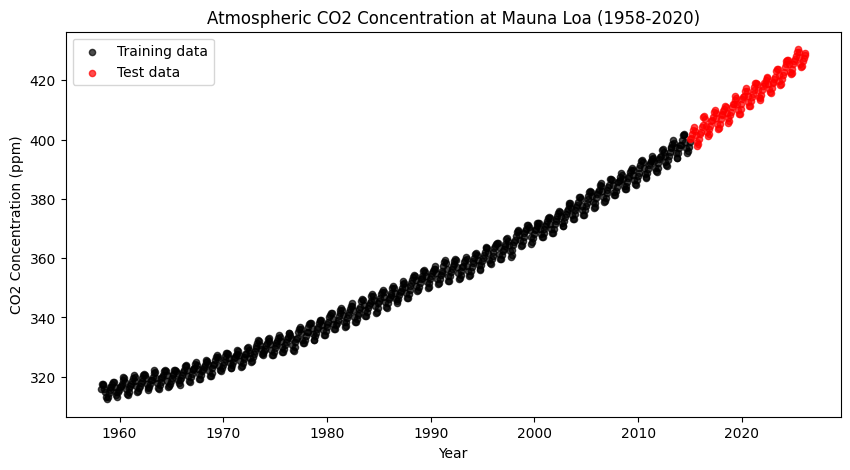

In [54]:
plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, s=20, alpha=0.7, color='black', label='Training data')
plt.scatter(x_test, y_test, s=20, alpha=0.7, color='red', label='Test data')
plt.title('Atmospheric CO2 Concentration at Mauna Loa (1958-2020)')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.legend()
plt.show()

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 55 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit a

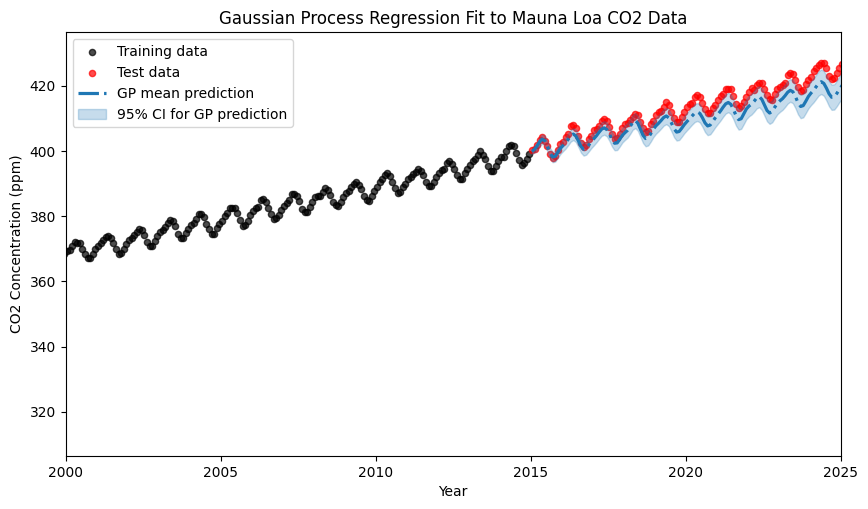

In [77]:
kernel = (
    1e+3 * RBF(length_scale=390)  # long-term rising trend
    + 2.33**2  * ExpSineSquared(length_scale=1.26, periodicity=1.09)  # long-term variations with annual periodicity
    + 0.596**2 * RationalQuadratic(alpha=0.145, length_scale=4.74)   # medium and short-term variations
    + 0.183**2 * RBF(length_scale=0.133)  # Noise component with short length scale to capture high-frequency variations
    + WhiteKernel(noise_level=0.0111)  # White noise component to capture measurement noise
    )
gp = GaussianProcessRegressor(kernel=kernel, random_state=2026, n_restarts_optimizer=10, normalize_y=True)
gp.fit(x_train[:, None], y_train)   

y_pred, y_std = gp.predict(x_test[:, None], return_std=True)

plt.figure(figsize=(10, 5.5))
plt.scatter(x_train, y_train, s=20, alpha=0.7, color='black', label='Training data')
plt.scatter(x_test, y_test, s=20, alpha=0.7, color='red', label='Test data')
plt.plot(x_test, y_pred, color='tab:blue', linewidth=2.3, linestyle='-.', label='GP mean prediction')
plt.fill_between(x_test, y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, color='tab:blue', alpha=0.25, label='95% CI for GP prediction')
plt.title('Gaussian Process Regression Fit to Mauna Loa CO2 Data')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.xlim(2000, 2025)
plt.legend()
plt.show()

Fitting on CO2 concentration data from Mauna Loa (1958-2020). We use a composite kernel combining periodic and rational quadratic components to capture both long-term trends and seasonal variations. The GP model provides a good fit to the data, with the mean prediction closely following the observed CO2 levels. The 95% confidence intervals capture the variability in the data, including seasonal fluctuations. Computational complexity is manageable for this dataset, but for larger datasets, sparse approximations or inducing points may be necessary to reduce computational load while maintaining predictive performance.

## Problem 3.3: ARIMA Modeling (25 points)
Forecast stock prices using ARIMA:

• Download daily prices for any stock (2+ years of data).

• Check for stationarity using ADF test.

• Use ACF/PACF plots to determine ARIMA order.

• Fit ARIMA model and validate using last 20% of data.

• Generate 30-day forecast with confidence intervals.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Load the data

[*********************100%***********************]  1 of 1 completed


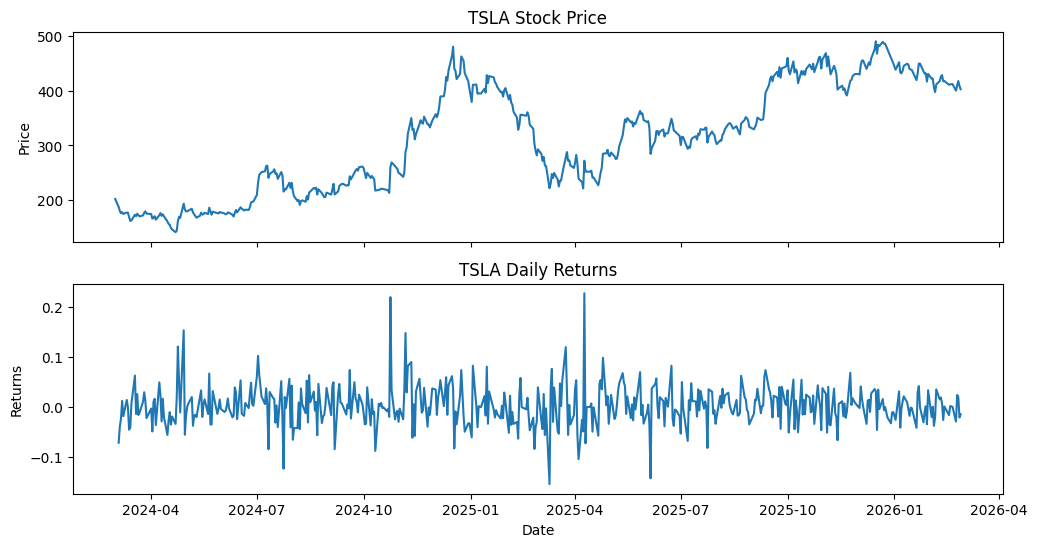

In [82]:
ticker = 'TSLA'
data = yf.download(ticker, start='2024-03-01', end='2026-03-01')
prices = data['Close'][ticker]
returns = prices.pct_change().dropna()
fig, ax = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
ax[1].plot(returns.index, returns.values)
ax[0].plot(prices.index, prices.values)
ax[0].set_title(f'{ticker} Stock Price')
ax[1].set_title(f'{ticker} Daily Returns')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('Price')
ax[1].set_ylabel('Returns')

plt.show()

In [83]:
# Split data into train and test sets
train, test = train_test_split(returns, test_size=0.2, shuffle=False)
prices_train, prices_test = train_test_split(prices, test_size=0.2, shuffle=False)

### Exploratory

In [84]:
print(f'Train size: {len(train)}, Test size: {len(test)}')

# ADF Test
adf_result = adfuller(train)
print(f'\nADF Test:')
print(f'  ADF Statistic: {adf_result[0]}')
print(f'  p-value: {adf_result[1]}')
print(f'  Decision: {"Stationary" if adf_result[1] < 0.05 else "Non-Stationary"}')
print(f'\nDifferencing needed: {"Yes" if adf_result[1] >= 0.05 else "No"}')


Train size: 399, Test size: 100

ADF Test:
  ADF Statistic: -19.97004161213686
  p-value: 0.0
  Decision: Stationary

Differencing needed: No


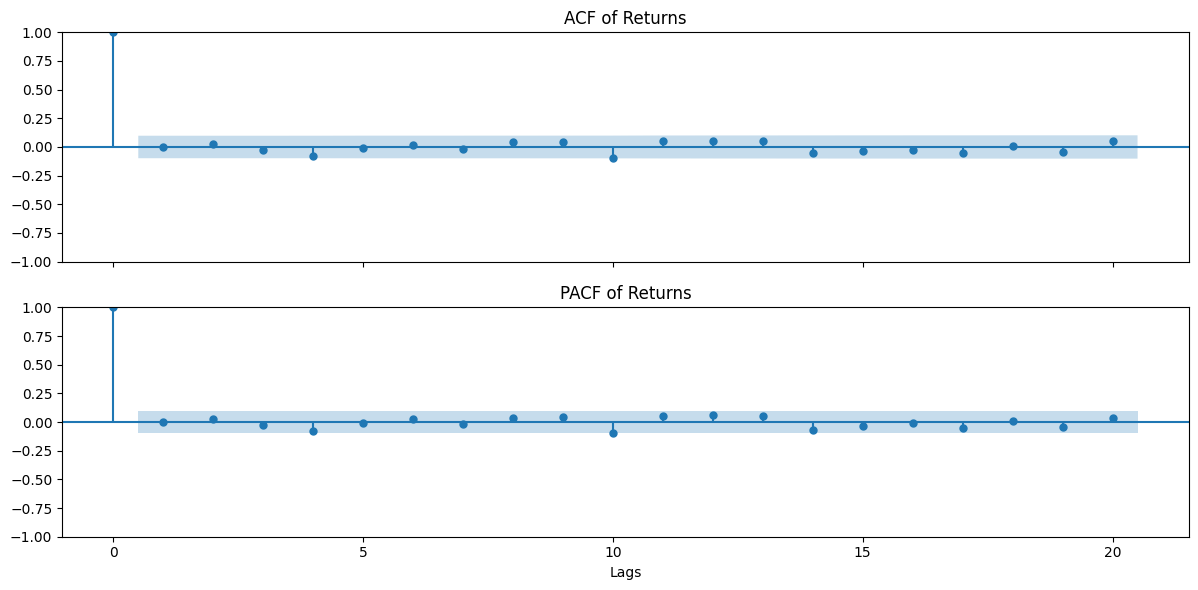

In [85]:
fig, ax = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
plot_acf(train, ax=ax[0], lags=20)
plot_pacf(train, ax=ax[1], lags=20)
ax[1].set_xlabel('Lags')
ax[0].set_title('ACF of Returns')
ax[1].set_title('PACF of Returns')
plt.tight_layout()
plt.show()

### Model fitting

In [86]:
best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(train, order=(p, 0, q))
            results = model.fit()
            print(f'ARIMA({p},0,{q}) - AIC: {results.aic:.2f}, BIC: {results.bic:.2f}')
            if results.aic < best_aic:
                best_aic = results.aic
                best_order_aic = (p, 0, q)
            if results.bic < best_bic:
                best_bic = results.bic
                best_order_bic = (p, 0, q)
        except Exception as e:
            print(f'Error fitting ARIMA({p},0,{q}): {e}')
print(f'\nBest AIC: {best_aic} with order {best_order_aic}')
print(f'Best BIC: {best_bic} with order {best_order_bic}')

ARIMA(0,0,0) - AIC: -1388.38, BIC: -1380.41
ARIMA(0,0,1) - AIC: -1386.38, BIC: -1374.42
ARIMA(0,0,2) - AIC: -1384.65, BIC: -1368.69
ARIMA(0,0,3) - AIC: -1382.87, BIC: -1362.93
ARIMA(1,0,0) - AIC: -1386.38, BIC: -1374.42
ARIMA(1,0,1) - AIC: -1384.38, BIC: -1368.43
ARIMA(1,0,2) - AIC: -1382.41, BIC: -1362.46
ARIMA(1,0,3) - AIC: -1381.86, BIC: -1357.93
ARIMA(2,0,0) - AIC: -1384.60, BIC: -1368.65
ARIMA(2,0,1) - AIC: -1382.60, BIC: -1362.66
ARIMA(2,0,2) - AIC: -1384.53, BIC: -1360.60
ARIMA(2,0,3) - AIC: -1380.72, BIC: -1352.80
ARIMA(3,0,0) - AIC: -1382.85, BIC: -1362.91
ARIMA(3,0,1) - AIC: -1381.89, BIC: -1357.96
ARIMA(3,0,2) - AIC: -1381.42, BIC: -1353.49
ARIMA(3,0,3) - AIC: -1380.30, BIC: -1348.39

Best AIC: -1388.3840692552144 with order (0, 0, 0)
Best BIC: -1380.4061464214346 with order (0, 0, 0)


In [87]:
# Based on AIC and BIC, we choose random walk
model = ARIMA(train, order=(0, 0, 0))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                  399
Model:                          ARIMA   Log Likelihood                 696.192
Date:                Mon, 30 Mar 2026   AIC                          -1388.384
Time:                        12:35:39   BIC                          -1380.406
Sample:                             0   HQIC                         -1385.224
                                - 399                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.002      1.252      0.211      -0.002       0.007
sigma2         0.0018    7.5e-05     23.822      0.000       0.002       0.002
Ljung-Box (L1) (Q):                   0.00   Jarque-

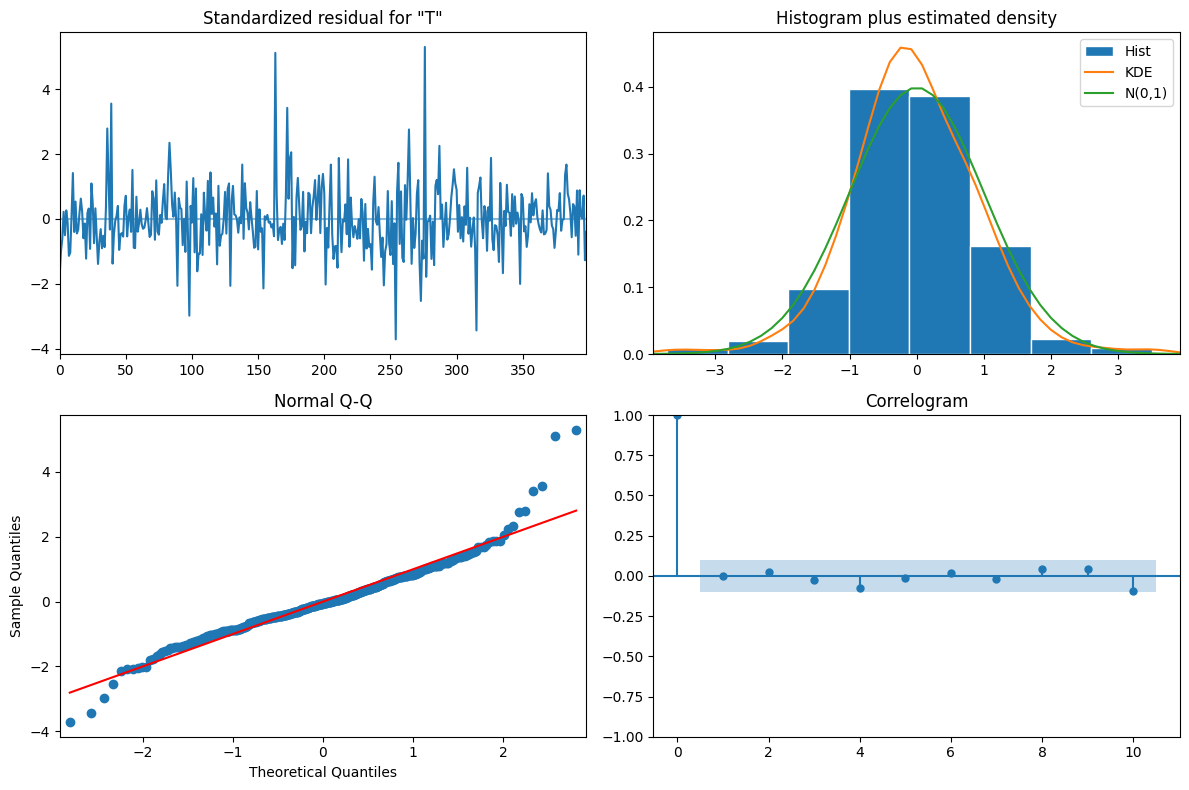

In [88]:
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Model evaluation
#### Test set forecast

In [89]:
pred_train = results.fittedvalues
pred_test = results.forecast(steps=len(test))
mse_train = mean_squared_error(train, pred_train)
mae_train = mean_absolute_error(train, pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train, pred_train)

mse_test = mean_squared_error(test, pred_test)
mae_test = mean_absolute_error(test, pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(test, pred_test)

metrics_df = pd.DataFrame({
    'MSE': [mse_train, mse_test],
    'MAE': [mae_train, mae_test],
    'RMSE': [rmse_train, rmse_test],
    'R2': [r2_train, r2_test]
}, index=["train", "test"])
metrics_df

,MSE,MAE,RMSE,R2
train,0.001786,0.030786,0.042266,-1.384553e-08
test,0.000723,0.021685,0.026882,-1.311901e-02


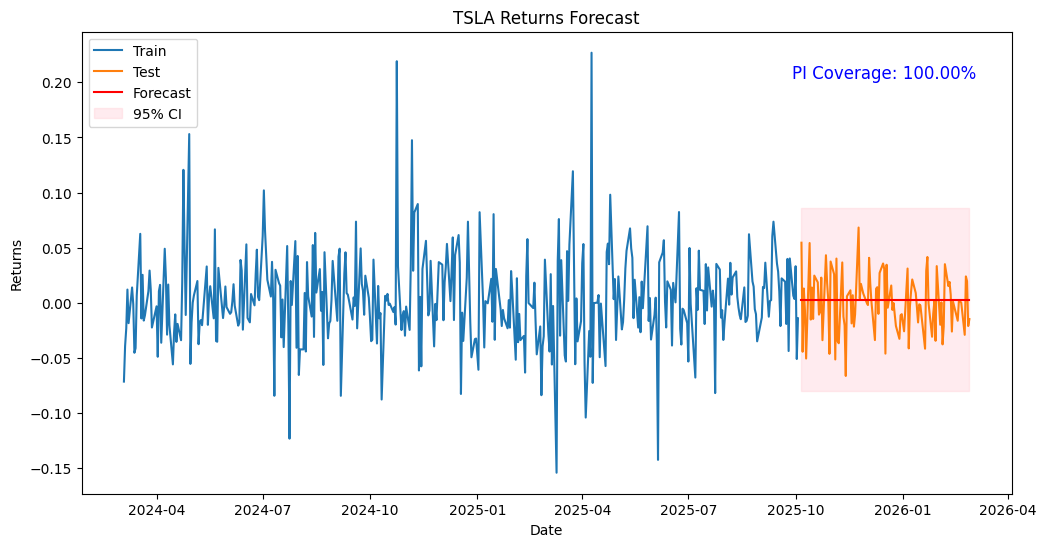

In [ ]:
forecast_steps = len(test)
forecast_result = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_mean.index = test.index[:forecast_steps]
forecast_ci = forecast_result.conf_int()
forecast_ci.index = forecast_mean.index
coverage = ((forecast_ci.iloc[:, 0] <= test[:forecast_steps]) & (test[:forecast_steps] <= forecast_ci.iloc[:, 1])).mean()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(test.index[:forecast_steps], forecast_mean.values, label='Forecast', color='red')
plt.fill_between(test.index[:forecast_steps], forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3, label='95% CI')
plt.text(test.index[forecast_steps//2], 0.2, f'PI Coverage: {coverage:.2%}', ha='center', va='bottom', fontsize=12, color='blue')
plt.title(f'{ticker} Returns Forecast')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

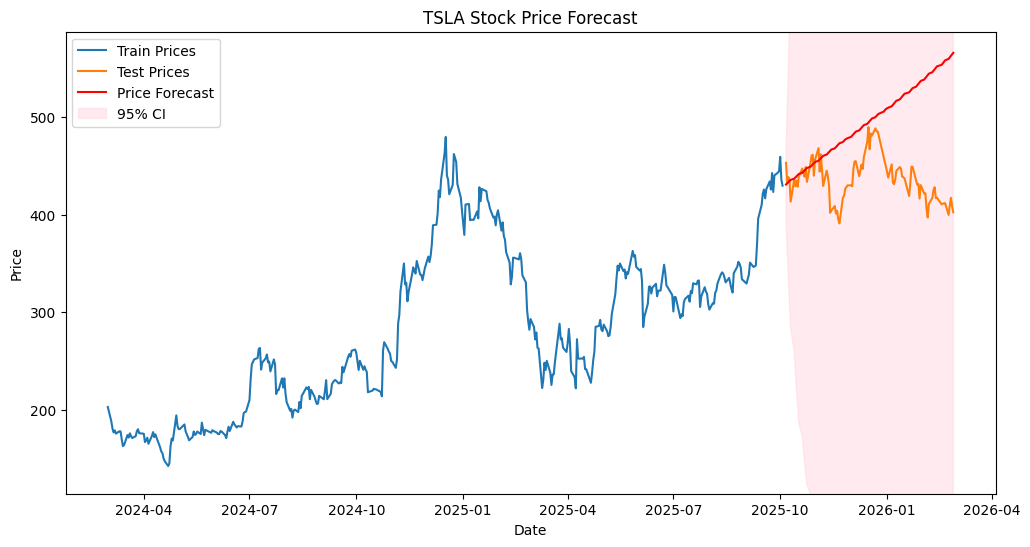

In [134]:
# Stock price forecast
last_price = prices_train.iloc[-1]
price_forecast = last_price * (1 + forecast_mean).cumprod()
price_PIs = last_price * (1 + forecast_ci).cumprod()


plt.figure(figsize=(12, 6))
plt.plot(prices_train.index, prices_train.values, label='Train Prices')
plt.plot(prices_test.index, prices_test.values, label='Test Prices')
plt.plot(test.index[:forecast_steps], price_forecast.values, label='Price Forecast', color='red')
plt.fill_between(test.index[:forecast_steps], price_PIs.iloc[:, 0], price_PIs.iloc[:, 1], color='pink', alpha=0.3, label='95% CI')
plt.ylim(prices.min() * 0.8, prices.max() * 1.2)
plt.title(f'{ticker} Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#### test set one step ahead forecast

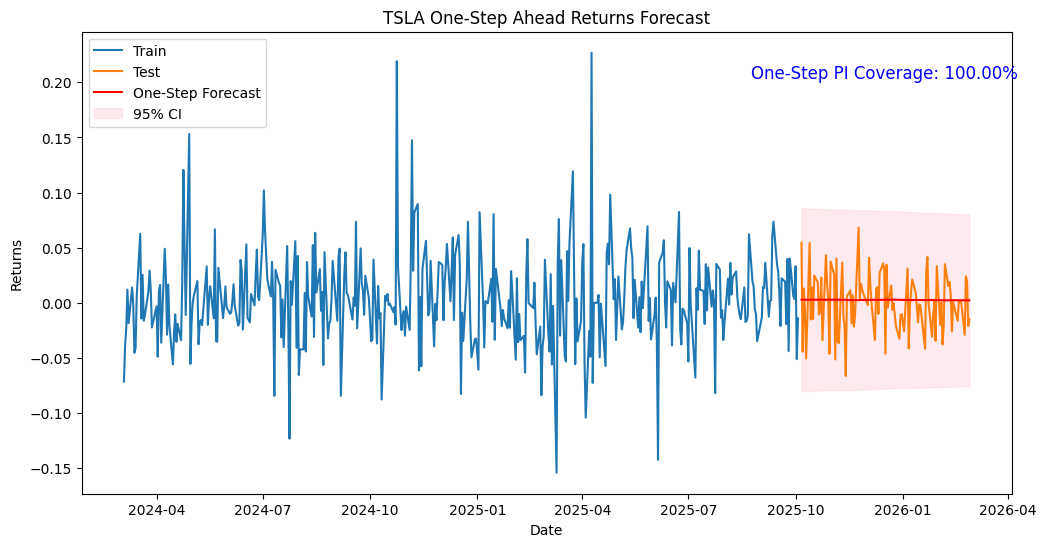

In [127]:
# one step ahead forecast + refit loop
history = list(train)
predictions = []
PIs = []
for t in range(len(test)):
    model = ARIMA(history, order=(0, 0, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    pi = model_fit.get_forecast(steps=1).conf_int()
    PIs.append(pi)
    predictions.append(yhat)
    history.append(test.iloc[t])
predictions = pd.Series(predictions, index=test.index)
PIs_df = pd.DataFrame(np.array(PIs).reshape(-1, 2), index=test.index, columns=['lower', 'upper'])
coverage_one_step = ((PIs_df['lower'] <= test) & (test <= PIs_df['upper'])).mean() 
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(predictions.index, predictions.values, label='One-Step Forecast', color='red')
plt.fill_between(PIs_df.index, PIs_df['lower'], PIs_df['upper'], color='pink', alpha=0.3, label='95% CI')
plt.text(test.index[len(test)//2], 0.2, f'One-Step PI Coverage: {coverage_one_step:.2%}', ha='center', va='bottom', fontsize=12, color='blue')
plt.title(f'{ticker} One-Step Ahead Returns Forecast')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

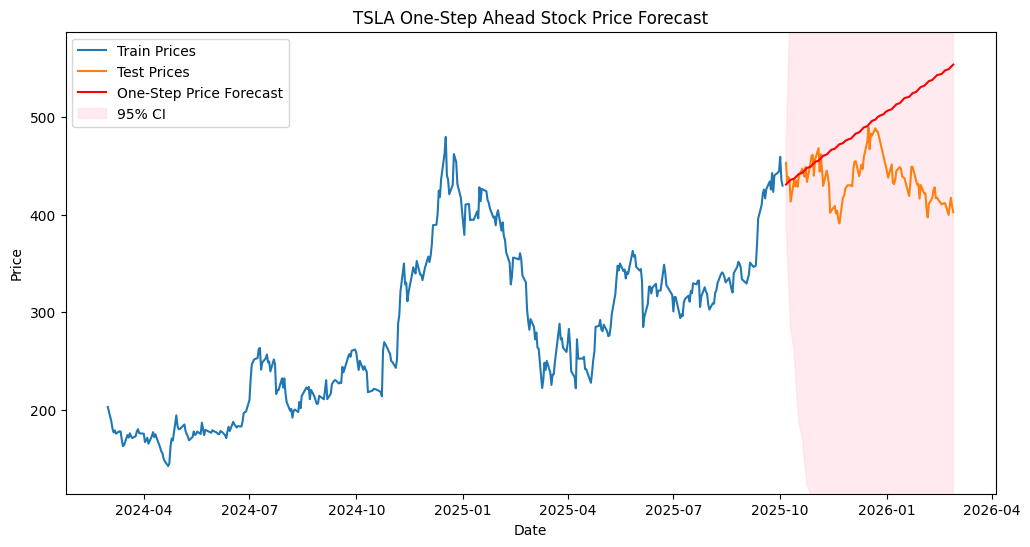

In [130]:
# now for stock price
last_price = prices_train.iloc[-1]
price_predictions = last_price * (1 + predictions).cumprod()
price_PIs_lower = last_price * (1 + PIs_df['lower']).cumprod()
price_PIs_upper = last_price * (1 + PIs_df['upper']).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(prices_train.index, prices_train.values, label='Train Prices')
plt.plot(prices_test.index, prices_test.values, label='Test Prices')
plt.plot(predictions.index, price_predictions.values, label='One-Step Price Forecast', color='red')
plt.fill_between(price_PIs_lower.index, price_PIs_lower.values, price_PIs_upper.values, color='pink', alpha=0.3, label='95% CI')
plt.ylim(prices.min() * 0.8, prices.max() * 1.2)
plt.title(f'{ticker} One-Step Ahead Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## Problem 3.4: GARCH for Volatility (25 points)
Model volatility clustering in financial returns:

• Calculate daily returns for S&P 500 index.

• Fit GARCH(1,1) model to returns.

• Forecast volatility for next 20 days.

• Validate using realized volatility.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from datetime import datetime

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


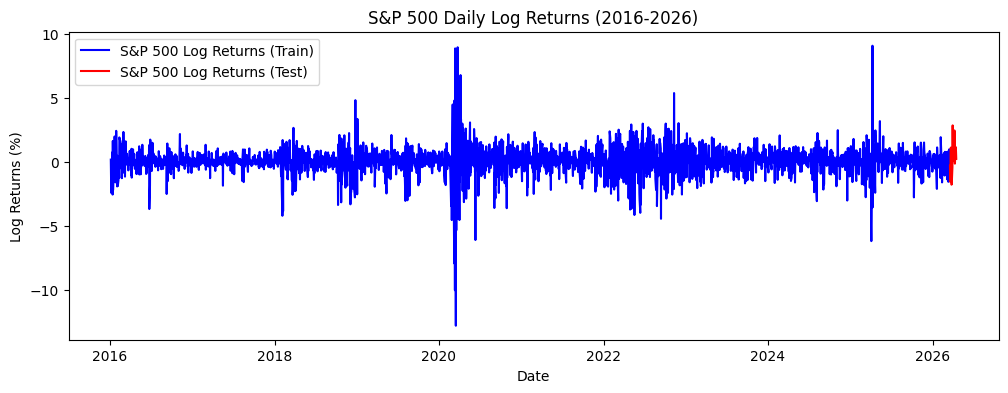

In [89]:
spx = yf.download('^GSPC', start='2016-01-01', end=datetime.now().date()) # set end date to today's date
spx['logReturns'] = np.log(spx['Close'] / spx['Close'].shift(1)).dropna() * 100
train = spx['logReturns'][1:-20]
test = spx['logReturns'][-20:]

# intraday 15m period data
intraday_data = yf.download('^GSPC', period='20d', interval='15m', end=test.index[-1].date())
intraday_data['logReturns'] = np.log(intraday_data['Close'] / intraday_data['Close'].shift(1)).dropna() * 100
intraday_realized_volatility_daily = intraday_data.groupby(intraday_data.index.date)['logReturns'].apply(lambda x: np.sqrt(np.sum(x**2)))

plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='S&P 500 Log Returns (Train)', color='blue')
plt.plot(test.index, test, label='S&P 500 Log Returns (Test)', color='red')
plt.title('S&P 500 Daily Log Returns (2016-2026)')
plt.xlabel('Date')
plt.ylabel('Log Returns (%)')
plt.legend()
plt.show()

Volatility clustering is a common phenomenon in financial markets where periods of high volatility are followed by more high volatility, and periods of low volatility are followed by more low volatility. It can be observed in the S&P 500 index returns. It can be easily observred during Trump's election (November 2016); COVID-19 pandemic (March 2020); war in Ukraine (year 2022); Trump's tariffs (March 2025).

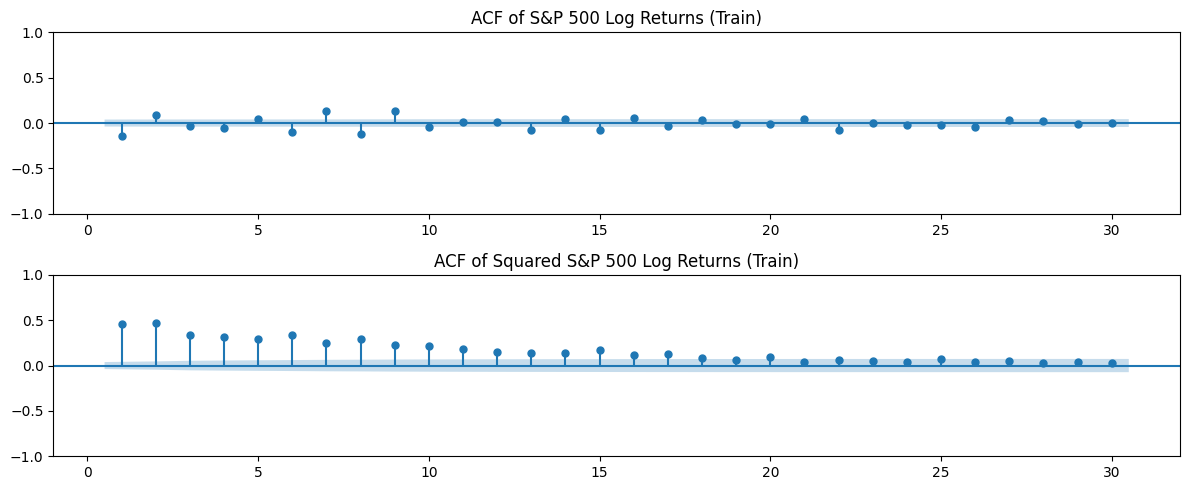

In [90]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(2, 1, figsize=(12, 5))
plot_acf(train, lags=30, ax=ax[0], zero=False)
plot_acf(train**2, lags=30, ax=ax[1], zero=False)
ax[0].set_title('ACF of S&P 500 Log Returns (Train)')
ax[1].set_title('ACF of Squared S&P 500 Log Returns (Train)')
plt.tight_layout()
plt.show()

In [91]:
from arch import arch_model
garch_model = arch_model(train, vol='Garch', p=1, q=1, mean='Constant', dist='Normal')
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             logReturns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3303.01
Distribution:                  Normal   AIC:                           6614.01
Method:            Maximum Likelihood   BIC:                           6637.41
                                        No. Observations:                 2565
Date:                Fri, Apr 17 2026   Df Residuals:                     2564
Time:                        14:51:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0799  1.478e-02      5.409  6.330e-08 [5.098e-0

$\beta \approx 0.8$ coefficient is much higher than $\alpha \approx 0.15$ which means that volatility is more influenced by its own past values than by the magnitude of recent shocks. This is a common finding in financial time series, indicating that volatility tends to persist over time, leading to the phenomenon of volatility clustering.

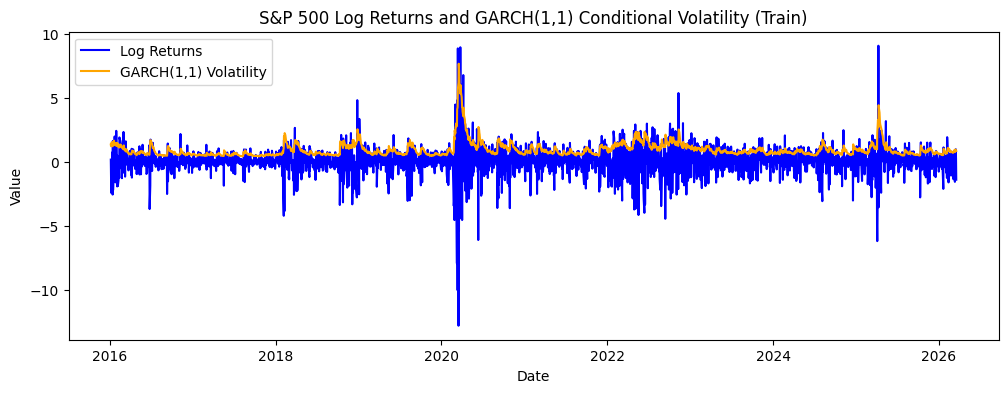

In [92]:
# illustrate insample volatility clustering
plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Log Returns', color='blue')
plt.plot(train.index, garch_fit.conditional_volatility, label='GARCH(1,1) Volatility', color='orange')
plt.title('S&P 500 Log Returns and GARCH(1,1) Conditional Volatility (Train)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

Volatility clustering in periods mentioned before has been captured by the GARCH(1,1) model, which shows increased conditional volatility during those times. 

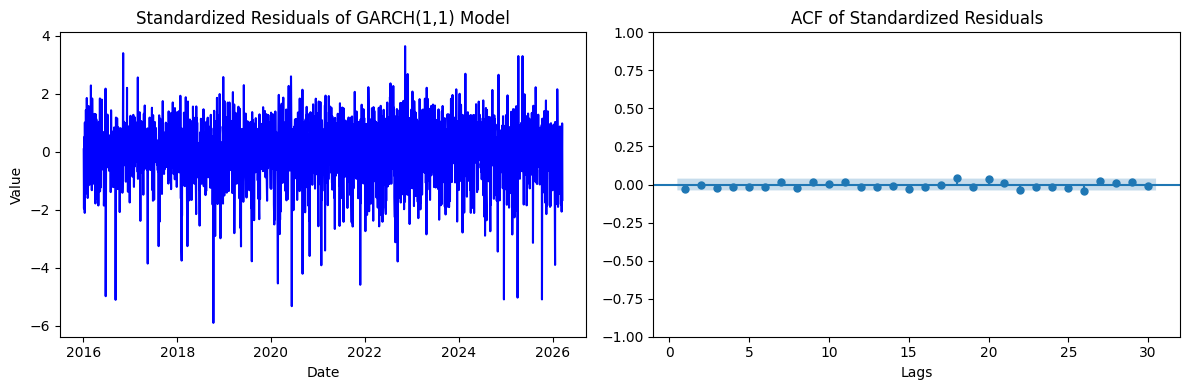

In [93]:
# standardized residuals analysis
standardized_residuals = garch_fit.resid / garch_fit.conditional_volatility
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(standardized_residuals, label='Standardized Residuals', color='blue')
plt.title('Standardized Residuals of GARCH(1,1) Model')
plt.xlabel('Date')
plt.ylabel('Value')

plt.subplot(1, 2, 2)
plot_acf(standardized_residuals, lags=30, ax=plt.gca(), zero=False)
plt.title('ACF of Standardized Residuals')
plt.xlabel('Lags')

plt.tight_layout()
plt.show()


Standardized residuals of the GARCH(1,1) model show no significant autocorrelation nor patterns, suggesting that the model has adequately captured the volatility dynamics in the data.

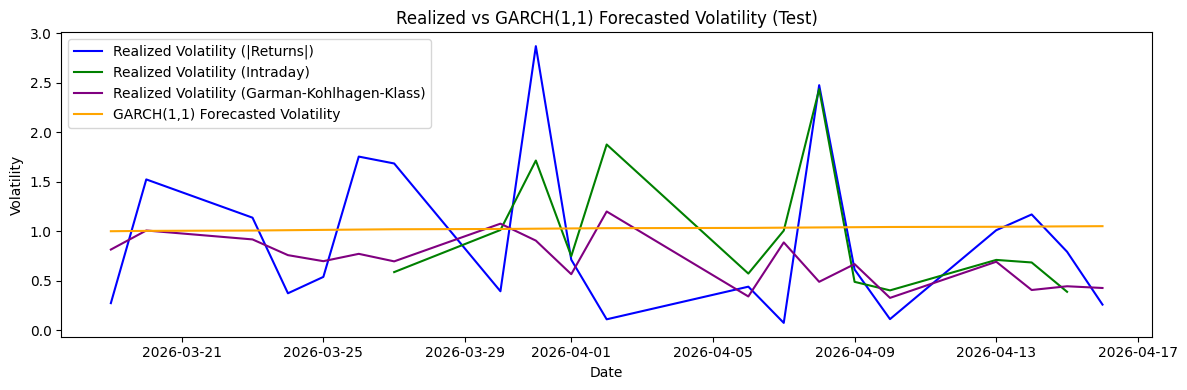

In [117]:
forecasts = garch_fit.forecast(horizon=20)
forecasted_vol = np.sqrt(forecasts.variance.values[-1, :])

# compare forecasts with realized volatilities (squared returns)
realized_vol = np.sqrt(test**2)

# garman kohlhagen-klass volatility estimator
def garman_kohlhagen_klass(high, low, open_, close):
    return np.sqrt(0.5 * (np.log(high / low))**2 - (2 * np.log(2) - 1) * (np.log(close / open_))**2)

g_k_realized_vol = spx[spx.index.isin(test.index)].apply(lambda x: garman_kohlhagen_klass(x['High'], x['Low'], x['Open'], x['Close']), axis=1).values * 100


plt.figure(figsize=(12, 4))
plt.plot(test.index, realized_vol, label='Realized Volatility (|Returns|)', color='blue')
plt.plot(intraday_realized_volatility_daily.index, intraday_realized_volatility_daily.values, label='Realized Volatility (Intraday)', color='green')
plt.plot(test.index, g_k_realized_vol, label='Realized Volatility (Garman-Kohlhagen-Klass)', color='purple')
plt.plot(test.index, forecasted_vol, label='GARCH(1,1) Forecasted Volatility', color='orange')
plt.title('Realized vs GARCH(1,1) Forecasted Volatility (Test)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()